# OilyGiant: ¿en qué región abrir nuevos pozos de petróleo?

## Objetivo

* La empresa OilyGiant quiere abrir 200 pozos nuevos en una de tres regiones.
* Tenemos datos de exploración de 100 000 puntos por región, con las reservas medidas en cada uno (`product`).
* Hay que elegir la región que deje más ganancia, pero solo si el riesgo de pérdida es menor al 2.5%.

**Condiciones del proyecto:**

* En cada región se exploran 500 puntos y se eligen los 200 mejores según el modelo.
* El presupuesto para los 200 pozos es de 100 millones de USD.
* Cada unidad de producto (1000 barriles) deja 4500 USD.
* Solo se puede usar regresión lineal.

## 1. Librerías y parámetros

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 12345
DATA_DIR = Path("../data/raw")
FEATURES = ["f0", "f1", "f2"]

BUDGET = 100_000_000  # inversión para los 200 pozos (USD)
REVENUE_PER_UNIT = 4_500  # USD por cada 1000 barriles
POINTS_EXPLORED = 500
WELLS_SELECTED = 200

sns.set_theme(style="whitegrid")

## 2. Carga y revisión de datos

In [2]:
regions = {r: pd.read_csv(DATA_DIR / f"geo_data_{r}.csv") for r in [0, 1, 2]}

for r, data in regions.items():
    print(
        f"Región {r}: {data.shape}, nulos: {data.isna().sum().sum()}, "
        f"filas duplicadas: {data.duplicated().sum()}, id duplicados: {data['id'].duplicated().sum()}"
    )

Región 0: (100000, 5), nulos: 0, filas duplicadas: 0, id duplicados: 10
Región 1: (100000, 5), nulos: 0, filas duplicadas: 0, id duplicados: 4
Región 2: (100000, 5), nulos: 0, filas duplicadas: 0, id duplicados: 4


In [3]:
regions[0].head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


* No hay nulos ni filas duplicadas.
* Pero algunos `id` se repiten con valores diferentes. Como no sabemos cuál medición es la correcta y son muy pocos, eliminamos esas filas.

In [4]:
regions = {r: data[~data["id"].duplicated(keep=False)].reset_index(drop=True) for r, data in regions.items()}

for r, data in regions.items():
    print(f"Región {r}: {len(data)} filas, reservas promedio: {data['product'].mean():.2f}")

Región 0: 99980 filas, reservas promedio: 92.50
Región 1: 99992 filas, reservas promedio: 68.82
Región 2: 99992 filas, reservas promedio: 95.00


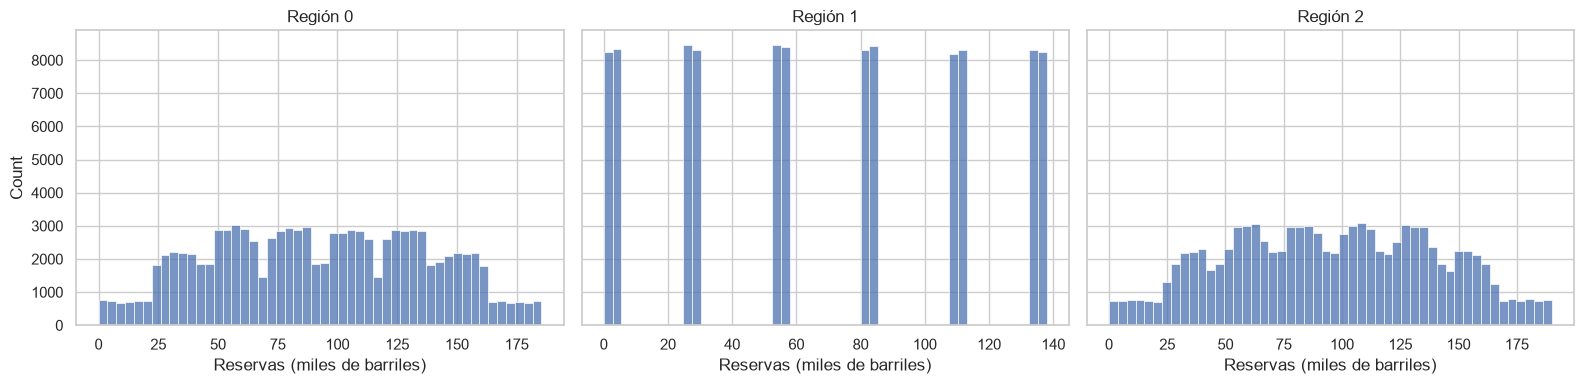

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (r, data) in zip(axes, regions.items()):
    sns.histplot(data["product"], bins=50, ax=ax)
    ax.set_title(f"Región {r}")
    ax.set_xlabel("Reservas (miles de barriles)")
plt.tight_layout()
plt.show()

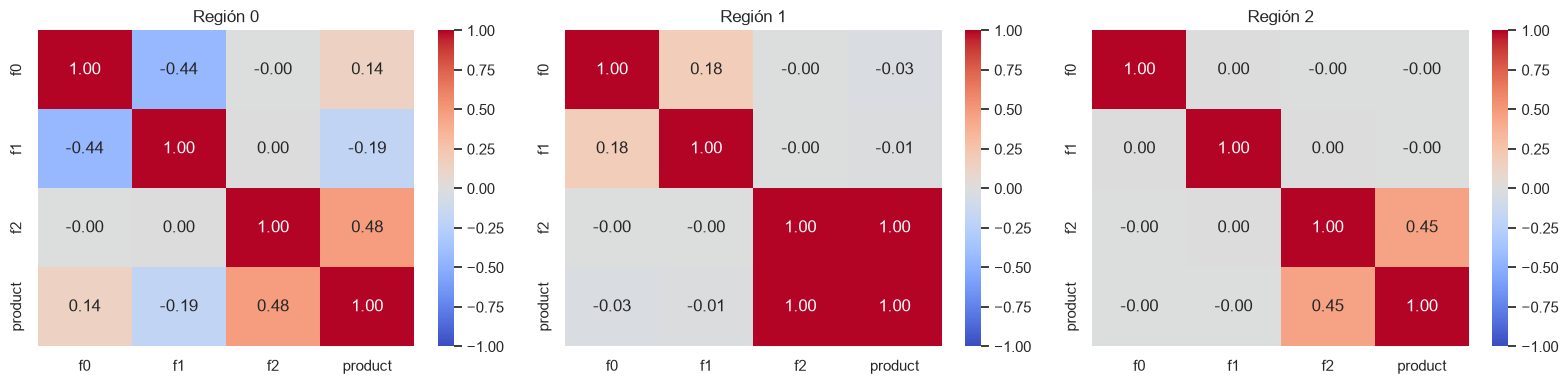

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (r, data) in zip(axes, regions.items()):
    sns.heatmap(data[FEATURES + ["product"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"Región {r}")
plt.tight_layout()
plt.show()

* Las regiones 0 y 2 tienen en promedio más reservas (92 y 95 mil barriles) que la región 1 (69 mil).
* La región 1 es rara: sus reservas solo toman unos pocos valores, y `f2` tiene una correlación casi perfecta con `product`. Eso hace pensar que la regresión lineal va a ser muy precisa en esa región.

## 3. Modelo por región

* Creamos una función que separa los datos en 75% entrenamiento y 25% validación, entrena la regresión lineal y devuelve las predicciones junto con los valores reales.

In [7]:
def train_and_predict(data):
    X_train, X_valid, y_train, y_valid = train_test_split(
        data[FEATURES], data["product"], test_size=0.25, random_state=RANDOM_STATE
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = pd.Series(model.predict(X_valid), index=y_valid.index)
    return predictions, y_valid


validation = {r: train_and_predict(data) for r, data in regions.items()}

for r, (predictions, y_valid) in validation.items():
    rmse = root_mean_squared_error(y_valid, predictions)
    print(f"Región {r}: reservas promedio predichas = {predictions.mean():.2f}, RMSE = {rmse:.2f}")

Región 0: reservas promedio predichas = 92.42, RMSE = 37.72
Región 1: reservas promedio predichas = 68.98, RMSE = 0.89
Región 2: reservas promedio predichas = 95.12, RMSE = 39.98


* En la región 1 el RMSE es menor a 1, el modelo casi no se equivoca.
* En las regiones 0 y 2 el RMSE es de unos 38-40 mil barriles, o sea que las predicciones de cada pozo tienen mucho error.

## 4. ¿Cuánto debe tener un pozo para no perder dinero?

In [8]:
break_even = BUDGET / WELLS_SELECTED / REVENUE_PER_UNIT
print(f"Cada pozo necesita al menos {break_even:.1f} mil barriles para no tener pérdidas")

Cada pozo necesita al menos 111.1 mil barriles para no tener pérdidas


* El promedio de las tres regiones está por debajo de 111.1, así que si abrimos pozos al azar perdemos dinero.
* Por eso necesitamos el modelo: para elegir los mejores puntos.

## 5. Ganancia de los 200 mejores pozos

* Elegimos los 200 pozos con mayor reserva **predicha**, pero la ganancia la calculamos con sus reservas **reales**, porque eso es lo que de verdad se va a extraer.

In [9]:
def calculate_profit(predictions, target):
    best_wells = predictions.sort_values(ascending=False).head(WELLS_SELECTED).index
    return target[best_wells].sum() * REVENUE_PER_UNIT - BUDGET


for r, (predictions, y_valid) in validation.items():
    profit = calculate_profit(predictions, y_valid)
    print(f"Región {r}: ganancia = {profit / 1e6:.2f} millones USD")

Región 0: ganancia = 31.36 millones USD
Región 1: ganancia = 24.15 millones USD
Región 2: ganancia = 24.66 millones USD


* Aquí elegimos entre unos 25 000 puntos de validación, pero en la realidad solo se exploran 500 por región. Para ver qué pasa en ese caso usamos bootstrapping.

## 6. Riesgo con bootstrapping

* Simulamos 1000 veces la exploración: tomamos 500 puntos al azar, elegimos los 200 mejores según el modelo y calculamos la ganancia.
* Con esas 1000 ganancias sacamos el promedio, el intervalo de confianza del 95% y el riesgo de pérdida (cuántas veces la ganancia salió negativa).

In [10]:
def bootstrap_profit(predictions, target, n_samples=1000):
    state = np.random.RandomState(RANDOM_STATE)
    profits = []
    for _ in range(n_samples):
        sample = predictions.sample(n=POINTS_EXPLORED, replace=True, random_state=state)
        profits.append(calculate_profit(sample, target))
    return pd.Series(profits)


bootstrap = {r: bootstrap_profit(predictions, y_valid) for r, (predictions, y_valid) in validation.items()}

summary = pd.DataFrame({
    "ganancia_promedio": {r: p.mean() / 1e6 for r, p in bootstrap.items()},
    "limite_inferior_95": {r: p.quantile(0.025) / 1e6 for r, p in bootstrap.items()},
    "limite_superior_95": {r: p.quantile(0.975) / 1e6 for r, p in bootstrap.items()},
    "riesgo_perdida_%": {r: (p < 0).mean() * 100 for r, p in bootstrap.items()},
})
summary.round(2)

,ganancia_promedio,limite_inferior_95,limite_superior_95,riesgo_perdida_%
0,4.32,-0.81,9.41,5.5
1,4.78,0.52,8.98,2.0
2,3.22,-1.73,8.44,12.3


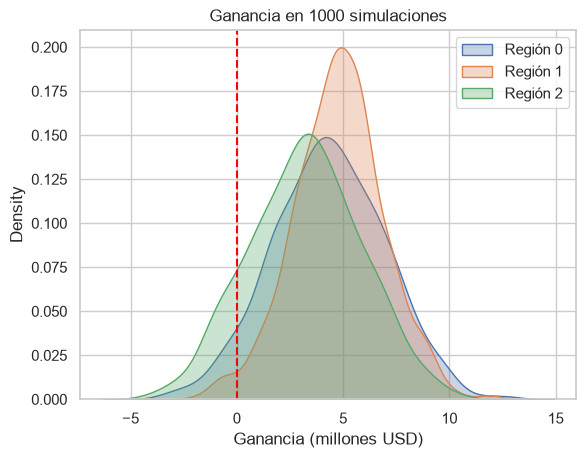

In [11]:
for r, profits in bootstrap.items():
    sns.kdeplot(profits / 1e6, label=f"Región {r}", fill=True, alpha=0.3)
plt.axvline(0, color="red", linestyle="--")
plt.title("Ganancia en 1000 simulaciones")
plt.xlabel("Ganancia (millones USD)")
plt.legend()
plt.show()

## 7. Conclusiones

| Región | RMSE | Ganancia promedio | Intervalo 95% | Riesgo de pérdida |
|---|---|---|---|---|
| 0 | 37.7 | 4.32 M | -0.81 a 9.41 M | 5.5% |
| **1** | **0.9** | **4.78 M** | **0.52 a 8.98 M** | **2.0%** |
| 2 | 40.0 | 3.22 M | -1.73 a 8.44 M | 12.3% |

* **Recomiendo la región 1.** Es la única con riesgo de pérdida menor al 2.5% y además tiene la ganancia promedio más alta.
* Aunque la región 1 tiene menos reservas en promedio, el modelo la predice casi perfecto, entonces los 200 pozos que elige son realmente buenos. En las regiones 0 y 2 el modelo se equivoca más y algunos pozos elegidos rinden menos de lo esperado.
* Lo que aprendí: en una decisión de inversión importa tanto la precisión del modelo como el promedio de las reservas.

**A tener en cuenta:**

* El riesgo de la región 1 (2.0%) está cerca del límite de 2.5%.
* Los datos de la región 1 se ven poco naturales (pocos valores distintos y correlación casi perfecta). Antes de invertir convendría confirmar con el equipo de geología que están bien.

**Corrección respecto a mi primera versión:** antes la función de ganancia tomaba un solo pozo (`np.sort(predictions)[-200]`) en lugar de los 200 mejores (`[-200:]`), y el bootstrap no simulaba la elección de los 500 puntos. Por eso todas las regiones daban pérdida y la conclusión era no invertir.